In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ends_df = pd.read_csv('./curling_database/ends.csv')
stones_df = pd.read_csv('./curling_database/stones.csv')
print(len(ends_df))
pp_active_rows = ends_df[ends_df['PowerPlay'] > 0].copy()
pp_game_ends = pp_active_rows[['CompetitionID', 'SessionID', 'GameID', 'EndID']].drop_duplicates()
pp_full_ends = pd.merge(ends_df, pp_game_ends, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
pp_full_ends

5274


,CompetitionID,SessionID,GameID,TeamID,EndID,Result,PowerPlay
0,0,1,1,19,6,0,NaN
1,0,1,1,27,6,1,1.0
2,0,1,1,19,7,0,1.0
3,0,1,1,27,7,3,NaN
4,0,1,2,20,6,0,NaN
...,...,...,...,...,...,...,...
1191,24250026,46,3,20,7,2,2.0
1192,24250026,48,1,37,6,0,2.0
1193,24250026,48,1,46,6,1,NaN
1194,24250026,49,1,14,6,3,2.0


In [3]:
def analyze_pp_outcome(group):
    # Find the row with PowerPlay > 0
    attacker = group[group['PowerPlay'] > 0].iloc[0]
    
    # The score of the ATTACKING team
    attacker_score = attacker['Result']
    
    # Define Defense Quality
    if attacker_score == 0:
        return 'Steal (Best)'
    elif attacker_score == 1:
        return 'Force (Good)'
    else:
        return 'Failure (Bad)'

outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')

In [4]:
first_shots = stones_df[stones_df['ShotID'] == 7]
first_shots

,CompetitionID,SessionID,GameID,EndID,ShotID,TeamID,PlayerID,Task,Handle,Points,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,1,7,19,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0,1,1,2,7,27,1,0,0,4,...,712.0,727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0,1,1,3,7,19,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30,0,1,1,4,7,27,1,0,0,3,...,775.0,1100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,0,1,1,5,7,19,1,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26320,24250026,49,1,3,7,14,1,0,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26330,24250026,49,1,4,7,24,1,0,0,4,...,766.0,731.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26340,24250026,49,1,5,7,24,1,0,1,4,...,743.0,737.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26350,24250026,49,1,6,7,24,1,4,0,4,...,77.0,1838.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
first_shots = stones_df[stones_df['ShotID'] == 7]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

In [6]:
analysis_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),7,19,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),7,27,1,0,0,...,1098.0,921.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),7,20,1,4,0,...,433.0,2008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),7,46,1,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),7,22,1,0,0,...,997.0,1897.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),7,46,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),7,20,1,4,0,...,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),7,10,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),7,46,1,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
analysis_df['Defense_Outcome'].value_counts(normalize=True)

Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: Defense_Outcome, dtype: float64

In [8]:
vals = analysis_df['Task'].value_counts()
vals

0     214
4     161
3      90
1      85
2      42
5       3
6       1
8       1
10      1
Name: Task, dtype: int64

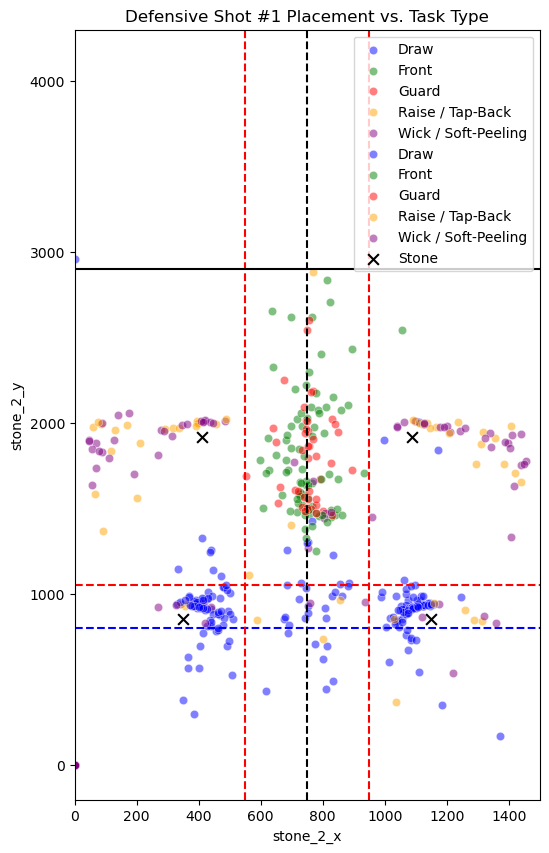

In [9]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[(analysis_df['Task']== 0) & (analysis_df['Points'] > 0)],
    x='stone_2_x', y='stone_2_y', color='blue', alpha=0.5, label='Draw'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 1) & (analysis_df['Points'] > 0)],
    x='stone_2_x', y='stone_2_y', color='green',alpha=0.5, label='Front'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 2) & (analysis_df['Points'] > 0)],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Guard'
)
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 3) & (analysis_df['Points'] > 0)],
    x='stone_2_x', y='stone_2_y', color='orange', alpha=0.5, label='Raise / Tap-Back'
)
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 4) & (analysis_df['Points'] > 0)],
    x='stone_2_x', y='stone_2_y', color='purple', alpha=0.5, label='Wick / Soft-Peeling'
)

sns.scatterplot(
    data=analysis_df[(analysis_df['Task']== 0) & (analysis_df['Points'] > 0)],
    x='stone_8_x', y='stone_8_y', color='blue', alpha=0.5, label='Draw'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 1) & (analysis_df['Points'] > 0)],
    x='stone_8_x', y='stone_8_y', color='green',alpha=0.5, label='Front'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 2) & (analysis_df['Points'] > 0)],
    x='stone_8_x', y='stone_8_y', color='red', alpha=0.5, label='Guard'
)
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 3) & (analysis_df['Points'] > 0)],
    x='stone_8_x', y='stone_8_y', color='orange', alpha=0.5, label='Raise / Tap-Back'
)
sns.scatterplot(
    data=analysis_df[(analysis_df['Task'] == 4) & (analysis_df['Points'] > 0)],
    x='stone_8_x', y='stone_8_y', color='purple', alpha=0.5, label='Wick / Soft-Peeling'
)
plt.scatter([350, 1150, 411, 1089], [850, 850, 1916, 1916], color='black', marker='x', s=60, label='Stone')


# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Task Type")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [10]:
# How often does each task succeed?
draw_success_df = analysis_df[analysis_df['Task'] == 0]
draw_success_rate = draw_success_df['Points'].value_counts(normalize=True) * 100
front_success_df = analysis_df[analysis_df['Task'] == 1]
front_success_rate = front_success_df['Points'].value_counts(normalize=True) * 100
guard_success_df = analysis_df[analysis_df['Task'] == 2]
guard_success_rate = guard_success_df['Points'].value_counts(normalize=True) * 100
raise_success_df = analysis_df[analysis_df['Task'] == 3]
raise_success_rate = raise_success_df['Points'].value_counts(normalize=True) * 100
wick_success_df = analysis_df[analysis_df['Task'] == 4]
wick_success_rate = wick_success_df['Points'].value_counts(normalize=True) * 100
"draw success rate", draw_success_rate, "front success rate", front_success_rate, "guard success rate", guard_success_rate, "raise success rate", raise_success_rate, "wick success rate", wick_success_rate

('draw success rate',
 4    52.803738
 3    23.364486
 2    14.485981
 0     8.411215
 1     0.934579
 Name: Points, dtype: float64,
 'front success rate',
 4    72.941176
 3    20.000000
 2     5.882353
 0     1.176471
 Name: Points, dtype: float64,
 'guard success rate',
 4    90.476190
 3     7.142857
 2     2.380952
 Name: Points, dtype: float64,
 'raise success rate',
 4    55.555556
 3    17.777778
 0    15.555556
 2     8.888889
 1     2.222222
 Name: Points, dtype: float64,
 'wick success rate',
 4    52.795031
 0    23.602484
 2    16.149068
 3     6.211180
 1     1.242236
 Name: Points, dtype: float64)

In [11]:
# How effectively each task defends against the Power Play?
draw_success_df = analysis_df[analysis_df['Task'] == 0]
draw_success_rate = draw_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
front_success_df = analysis_df[analysis_df['Task'] == 1]
front_success_rate = front_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
guard_success_df = analysis_df[analysis_df['Task'] == 2]
guard_success_rate = guard_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
raise_success_df = analysis_df[analysis_df['Task'] == 3]
raise_success_rate = raise_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
wick_success_df = analysis_df[analysis_df['Task'] == 4]
wick_success_rate = wick_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
"draw defense rate", draw_success_rate, "front defense rate", front_success_rate, "guard defense rate", guard_success_rate, "raise defense rate", raise_success_rate, "wick defense rate", wick_success_rate

('draw defense rate',
 Failure (Bad)    47.663551
 Force (Good)     32.242991
 Steal (Best)     20.093458
 Name: Defense_Outcome, dtype: float64,
 'front defense rate',
 Failure (Bad)    47.058824
 Force (Good)     30.588235
 Steal (Best)     22.352941
 Name: Defense_Outcome, dtype: float64,
 'guard defense rate',
 Failure (Bad)    50.000000
 Force (Good)     35.714286
 Steal (Best)     14.285714
 Name: Defense_Outcome, dtype: float64,
 'raise defense rate',
 Failure (Bad)    42.222222
 Force (Good)     34.444444
 Steal (Best)     23.333333
 Name: Defense_Outcome, dtype: float64,
 'wick defense rate',
 Failure (Bad)    46.583851
 Force (Good)     32.919255
 Steal (Best)     20.496894
 Name: Defense_Outcome, dtype: float64)

In [12]:
draw_success_df = analysis_df[(analysis_df['Task'] == 0) & (analysis_df['Points'] > 0)]
draw_success_rate = draw_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
front_success_df = analysis_df[(analysis_df['Task'] == 1) & (analysis_df['Points'] > 0)]
front_success_rate = front_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
guard_success_df = analysis_df[(analysis_df['Task'] == 2) & (analysis_df['Points'] > 0)]
guard_success_rate = guard_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
raise_success_df = analysis_df[(analysis_df['Task'] == 3) & (analysis_df['Points'] > 0)]
raise_success_rate = raise_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
wick_success_df = analysis_df[(analysis_df['Task'] == 4) & (analysis_df['Points'] > 0)]
wick_success_rate = wick_success_df['Defense_Outcome'].value_counts(normalize=True) * 100
"good draw defense rate", draw_success_rate, "good front defense rate", front_success_rate, "good guard defense rate", guard_success_rate, "good raise defense rate", raise_success_rate, "good wick defense rate", wick_success_rate

('good draw defense rate',
 Failure (Bad)    46.938776
 Force (Good)     32.653061
 Steal (Best)     20.408163
 Name: Defense_Outcome, dtype: float64,
 'good front defense rate',
 Failure (Bad)    46.428571
 Force (Good)     30.952381
 Steal (Best)     22.619048
 Name: Defense_Outcome, dtype: float64,
 'good guard defense rate',
 Failure (Bad)    50.000000
 Force (Good)     35.714286
 Steal (Best)     14.285714
 Name: Defense_Outcome, dtype: float64,
 'good raise defense rate',
 Failure (Bad)    43.421053
 Force (Good)     32.894737
 Steal (Best)     23.684211
 Name: Defense_Outcome, dtype: float64,
 'good wick defense rate',
 Failure (Bad)    46.341463
 Force (Good)     30.894309
 Steal (Best)     22.764228
 Name: Defense_Outcome, dtype: float64)

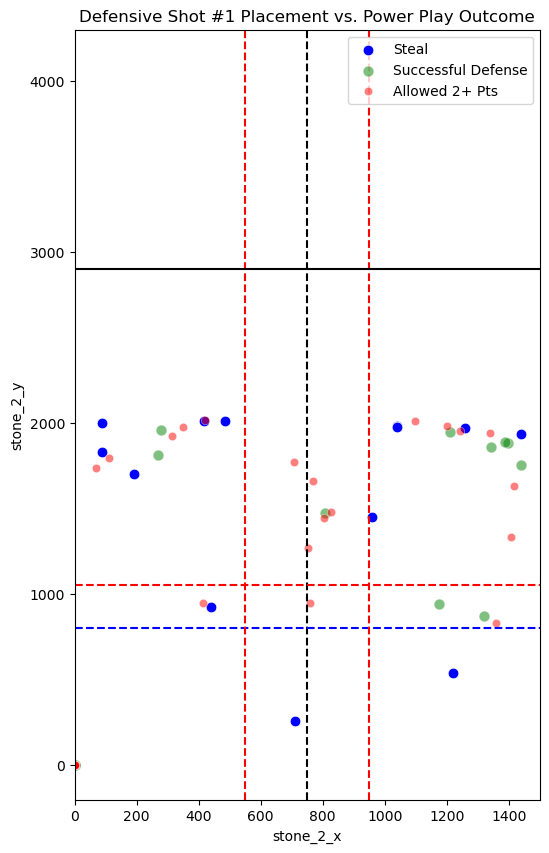

In [13]:
data = analysis_df[analysis_df['Task'] == 4]
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=data[data['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=data[data['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=data[data['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

# Looking at location not shot type

In [14]:
zero_count = analysis_df[(analysis_df['stone_2_x'] == 0) & (analysis_df['stone_2_y'] == 0)]
len(zero_count), len(analysis_df)

(295, 598)

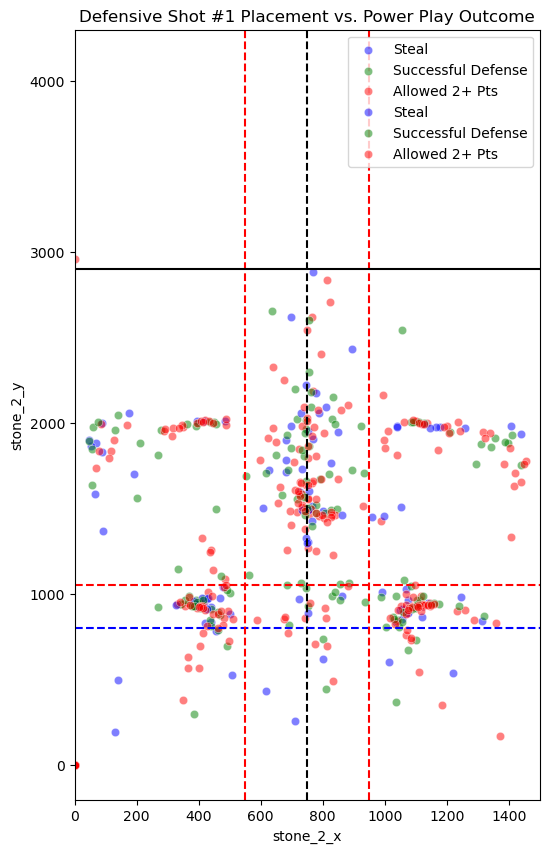

In [15]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', alpha=0.5, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_8_x', y='stone_8_y', color='blue', alpha=0.5, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_8_x', y='stone_8_y', color='green', alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_8_x', y='stone_8_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [16]:
# Define Condition 1: Stone 2 is in the zone
cond_stone_2 = (
    ((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & 
    ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750))
)

# Define Condition 2: Stone 8 is in the zone
cond_stone_8 = (
    ((analysis_df['stone_8_x'] < 550) | (analysis_df['stone_8_x'] > 950)) & 
    ((analysis_df['stone_8_y'] < 1050) & (analysis_df['stone_8_y'] > 750))
)

# Filter: Keep rows where EITHER condition is true
curious_zones = analysis_df[(cond_stone_2 | cond_stone_8) & (analysis_df['Task'] == 0)].copy()
shot_scores = curious_zones['Points'].value_counts(normalize=True)
print(shot_scores)
shot_types = curious_zones['Task'].value_counts(normalize=True)
print(shot_types)
success_rate = curious_zones['Defense_Outcome'].value_counts(normalize=True)
print(len(curious_zones))
print(success_rate)

4    0.646617
3    0.270677
2    0.082707
Name: Points, dtype: float64
0    1.0
Name: Task, dtype: float64
133
Failure (Bad)    0.443609
Force (Good)     0.330827
Steal (Best)     0.225564
Name: Defense_Outcome, dtype: float64


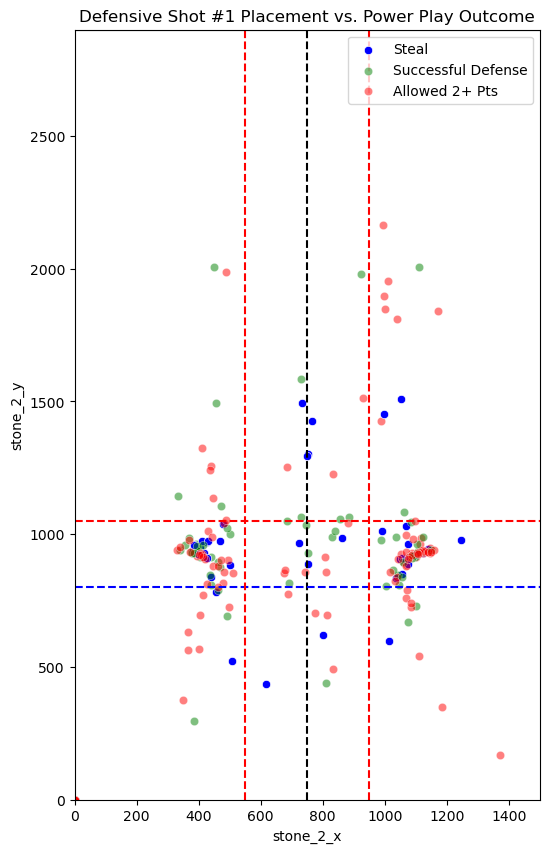

In [17]:
plt.figure(figsize=(6, 10))
draws = analysis_df[analysis_df['Task'] == 0]
sns.scatterplot(
    data=draws[draws['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=draws[draws['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=draws[draws['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)
sns.scatterplot(
    data=draws[draws['Defense_Outcome']== 'Steal (Best)'],
    x='stone_8_x', y='stone_8_y', color='blue'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=draws[draws['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_8_x', y='stone_8_y', color='green', alpha=0.5
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=draws[draws['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_8_x', y='stone_8_y', color='red', alpha=0.5
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.ylim(0, 2900)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

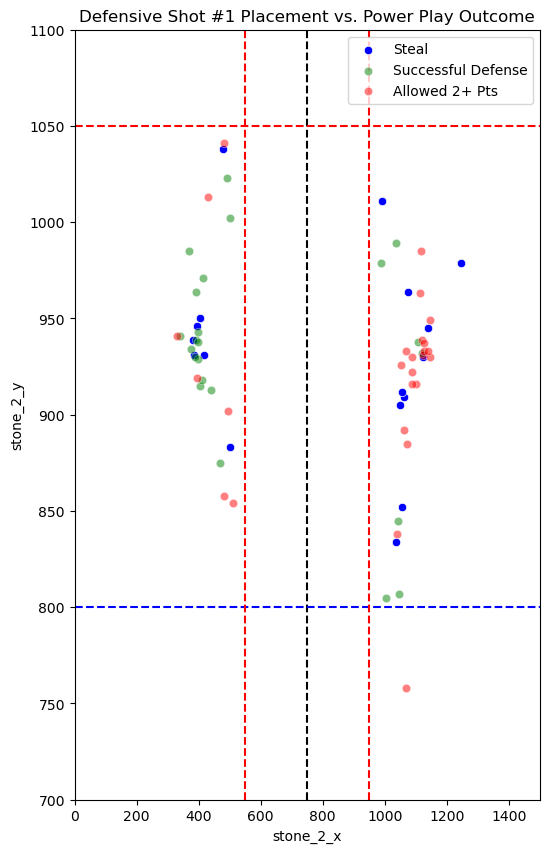

In [18]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.ylim(700, 1100)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [19]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
overall_rate

598


Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: Defense_Outcome, dtype: float64

In [20]:
center = analysis_df[(((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950)) | ((analysis_df['stone_8_x'] >= 550) & (analysis_df['stone_8_x'] <= 950)))]
center_rate = center['Defense_Outcome'].value_counts(normalize=True)
print(len(center))
center_rate

174


Failure (Bad)    0.465517
Force (Good)     0.327586
Steal (Best)     0.206897
Name: Defense_Outcome, dtype: float64

In [21]:
# center draws
cond_stone_2 = (
    ((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950))
)
cond_stone_8 = (
    ((analysis_df['stone_8_x'] >= 550) & (analysis_df['stone_8_x'] <= 950))
)

cd = analysis_df[(cond_stone_2 | cond_stone_8) & (analysis_df['Task'] == 0)].copy()
cd_points = cd['Points'].value_counts(normalize=True)
print(cd_points)
cd_rate = cd['Defense_Outcome'].value_counts(normalize=True)
print(len(cd))
cd_rate

4    0.617647
2    0.176471
0    0.117647
3    0.088235
Name: Points, dtype: float64
34


Failure (Bad)    0.382353
Force (Good)     0.352941
Steal (Best)     0.264706
Name: Defense_Outcome, dtype: float64

In [22]:
true_center = analysis_df[(((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_2_y'] <= 1050) & (analysis_df['stone_2_y'] >= 750)) | ((analysis_df['stone_8_x'] >= 550) & (analysis_df['stone_8_x'] <= 950) & (analysis_df['stone_8_y'] <= 1050) & (analysis_df['stone_8_y'] >= 750)))]
true_center_rate = true_center['Defense_Outcome'].value_counts(normalize=True)
print(len(true_center))
true_center_rate

19


Failure (Bad)    0.473684
Force (Good)     0.368421
Steal (Best)     0.157895
Name: Defense_Outcome, dtype: float64

In [23]:
high_center = analysis_df[(((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_2_y'] > 1050)) | ((analysis_df['stone_8_x'] >= 550) & (analysis_df['stone_8_x'] <= 950) & (analysis_df['stone_8_y'] > 1050)))]
high_center_rate = high_center['Defense_Outcome'].value_counts(normalize=True)
print(len(high_center))
high_center_rate

147


Failure (Bad)    0.469388
Force (Good)     0.326531
Steal (Best)     0.204082
Name: Defense_Outcome, dtype: float64

In [24]:
outside = analysis_df[((((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & (analysis_df['stone_8_x'] == 0)) | (((analysis_df['stone_8_x'] < 550) | (analysis_df['stone_8_x'] > 950)) & (analysis_df['stone_2_x'] == 0)))]
outside_rate = outside['Defense_Outcome'].value_counts(normalize=True)
print(len(outside))
outside_rate

424


Failure (Bad)    0.469340
Force (Good)     0.325472
Steal (Best)     0.205189
Name: Defense_Outcome, dtype: float64

In [25]:
outside_guard = analysis_df[(((analysis_df['stone_2_y'] > 1050) & ((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950))) | ((analysis_df['stone_8_y'] > 1050) & ((analysis_df['stone_8_x'] < 550) | (analysis_df['stone_8_x'] > 950))))]
outside_guard_rate = outside_guard['Defense_Outcome'].value_counts(normalize=True)
print(len(outside_guard))
outside_guard_rate

164


Failure (Bad)    0.487805
Force (Good)     0.310976
Steal (Best)     0.201220
Name: Defense_Outcome, dtype: float64

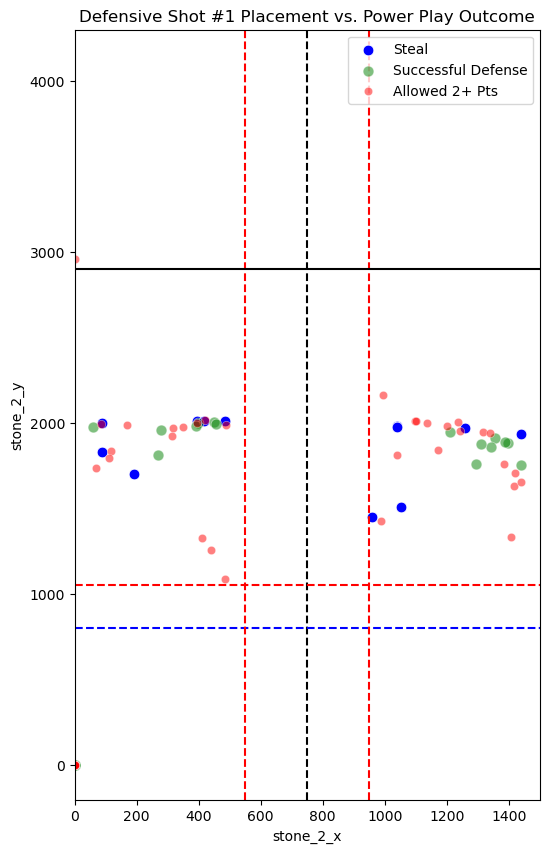

In [26]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

# Looking at second shots

In [27]:
first_shots = stones_df[stones_df['ShotID'] == 9]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

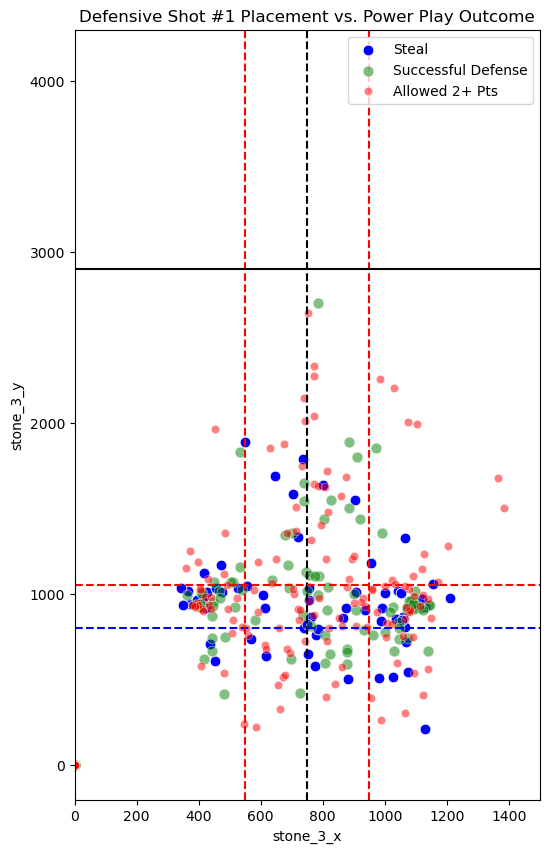

In [28]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_3_x', y='stone_3_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_3_x', y='stone_3_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_3_x', y='stone_3_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [29]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
print(overall_rate)
curious_zones = analysis_df[(((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750)) | ((analysis_df['stone_8_x'] < 550) | (analysis_df['stone_8_x'] > 950)) & ((analysis_df['stone_8_y'] < 1050) & (analysis_df['stone_8_y'] > 750)))]
success_rate = curious_zones['Defense_Outcome'].value_counts(normalize=True)
print(len(curious_zones))
print("outer central", success_rate)
center = analysis_df[(((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950)) | ((analysis_df['stone_8_x'] >= 550) & (analysis_df['stone_8_x'] <= 950)))]
center_rate = center['Defense_Outcome'].value_counts(normalize=True)
print(len(center))
print('center', center_rate)
outside = analysis_df[((((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & (analysis_df['stone_8_x'] == 0)) | (((analysis_df['stone_8_x'] < 550) | (analysis_df['stone_8_x'] > 950)) & (analysis_df['stone_2_x'] == 0)))]
outside_rate = outside['Defense_Outcome'].value_counts(normalize=True)
print(len(outside))
print('outside', outside_rate)

598
Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: Defense_Outcome, dtype: float64
286
outer central Failure (Bad)    0.472028
Force (Good)     0.297203
Steal (Best)     0.230769
Name: Defense_Outcome, dtype: float64
240
center Failure (Bad)    0.495833
Force (Good)     0.275000
Steal (Best)     0.229167
Name: Defense_Outcome, dtype: float64
0
outside Series([], Name: Defense_Outcome, dtype: float64)


In [30]:
first_shots = stones_df[(stones_df['ShotID'] == 9)]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

In [31]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
print('overall rate', overall_rate)
double_center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_3_x'] >= 550) & (analysis_df['stone_3_x'] <= 950))]
double_center_rate = double_center['Defense_Outcome'].value_counts(normalize=True)
print(len(double_center))
print('double center', double_center_rate)
out_in = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_3_x'] >= 550) & (analysis_df['stone_3_x'] <= 950))]
out_in_rate = out_in['Defense_Outcome'].value_counts(normalize=True)
print(len(out_in))
print('out in', out_in_rate)
double_out = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_3_x'] < 550) | (analysis_df['stone_3_x'] > 950))]
double_out_rate = double_out['Defense_Outcome'].value_counts(normalize=True)
print(len(double_out))
print('double out', double_out_rate)

598
overall rate Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: Defense_Outcome, dtype: float64
50
double center Failure (Bad)    0.56
Force (Good)     0.32
Steal (Best)     0.12
Name: Defense_Outcome, dtype: float64
76
out in Failure (Bad)    0.486842
Force (Good)     0.263158
Steal (Best)     0.250000
Name: Defense_Outcome, dtype: float64
392
double out Failure (Bad)    0.446429
Force (Good)     0.346939
Steal (Best)     0.206633
Name: Defense_Outcome, dtype: float64


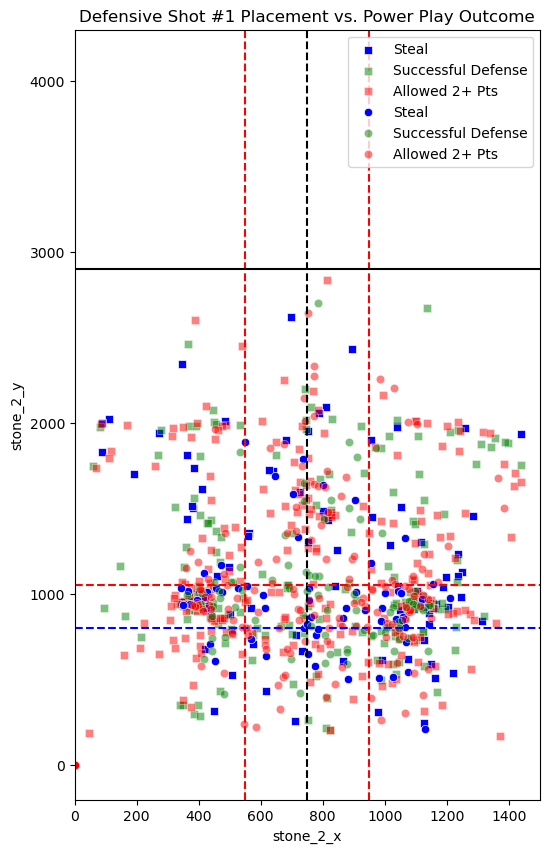

In [32]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', label='Steal', marker='s'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense', marker='s'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='s'
)

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_3_x', y='stone_3_y', color='blue', label='Steal', marker='o'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_3_x', y='stone_3_y', color='green', alpha=0.5, label='Successful Defense', marker='o'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_3_x', y='stone_3_y', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='o'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [33]:
ends_df = pd.read_csv('./curling_database/ends.csv')
stones_df = pd.read_csv('./curling_database/stones.csv')
print(len(ends_df))
pp_active_rows = ends_df[ends_df['PowerPlay'] > 0].copy()
pp_game_ends = pp_active_rows[['CompetitionID', 'SessionID', 'GameID', 'EndID']].drop_duplicates()
pp_full_ends = pd.merge(ends_df, pp_game_ends, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
pp_full_ends

5274


,CompetitionID,SessionID,GameID,TeamID,EndID,Result,PowerPlay
0,0,1,1,19,6,0,NaN
1,0,1,1,27,6,1,1.0
2,0,1,1,19,7,0,1.0
3,0,1,1,27,7,3,NaN
4,0,1,2,20,6,0,NaN
...,...,...,...,...,...,...,...
1191,24250026,46,3,20,7,2,2.0
1192,24250026,48,1,37,6,0,2.0
1193,24250026,48,1,46,6,1,NaN
1194,24250026,49,1,14,6,3,2.0


In [34]:
outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')

In [35]:
outcomes

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome
0,0,1,1,6,Force (Good)
1,0,1,1,7,Steal (Best)
2,0,1,2,6,Failure (Bad)
3,0,1,2,7,Failure (Bad)
4,0,1,3,6,Failure (Bad)
...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad)
594,24250026,46,3,6,Force (Good)
595,24250026,46,3,7,Failure (Bad)
596,24250026,48,1,6,Steal (Best)


In [36]:
first_shots = stones_df[stones_df['ShotID'] == 7]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
analysis_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),7,19,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),7,27,1,0,0,...,1098.0,921.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),7,20,1,4,0,...,433.0,2008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),7,46,1,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),7,22,1,0,0,...,997.0,1897.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),7,46,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),7,20,1,4,0,...,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),7,10,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),7,46,1,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
curious_zones = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750))]
curious_zones

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
5,0,1,3,7,Steal (Best),7,17,1,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,2,1,7,Failure (Bad),7,46,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,0,4,3,6,Force (Good),7,43,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46,0,9,1,7,Failure (Bad),7,27,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55,0,10,2,6,Steal (Best),7,27,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,24250026,14,5,8,Failure (Bad),7,34,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
559,24250026,16,3,6,Failure (Bad),7,17,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
577,24250026,18,2,8,Failure (Bad),7,17,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
584,24250026,41,1,7,Steal (Best),7,37,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
second_shots = stones_df[stones_df['ShotID'] == 9]
temp_df = pd.merge(outcomes, second_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
temp_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),9,19,2,0,0,...,1101.0,529.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),9,27,2,0,1,...,1098.0,921.0,652.0,794.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),9,20,2,0,0,...,433.0,2008.0,1046.0,759.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),9,46,2,0,1,...,1154.0,694.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),9,22,2,0,0,...,997.0,1897.0,923.0,1135.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),9,46,2,1,0,...,4095.0,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),9,20,2,0,1,...,4095.0,0.0,405.0,932.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),9,10,2,1,1,...,356.0,1456.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),9,46,2,0,0,...,776.0,708.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
follow_up_shots = temp_df.merge(curious_zones, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
follow_up_shots.columns

Index(['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Defense_Outcome_x',
       'ShotID_x', 'TeamID_x', 'PlayerID_x', 'Task_x', 'Handle_x', 'Points_x',
       'TimeOut_x', 'stone_1_x_x', 'stone_1_y_x', 'stone_2_x_x', 'stone_2_y_x',
       'stone_3_x_x', 'stone_3_y_x', 'stone_4_x_x', 'stone_4_y_x',
       'stone_5_x_x', 'stone_5_y_x', 'stone_6_x_x', 'stone_6_y_x',
       'stone_7_x_x', 'stone_7_y_x', 'stone_8_x_x', 'stone_8_y_x',
       'stone_9_x_x', 'stone_9_y_x', 'stone_10_x_x', 'stone_10_y_x',
       'stone_11_x_x', 'stone_11_y_x', 'stone_12_x_x', 'stone_12_y_x',
       'Defense_Outcome_y', 'ShotID_y', 'TeamID_y', 'PlayerID_y', 'Task_y',
       'Handle_y', 'Points_y', 'TimeOut_y', 'stone_1_x_y', 'stone_1_y_y',
       'stone_2_x_y', 'stone_2_y_y', 'stone_3_x_y', 'stone_3_y_y',
       'stone_4_x_y', 'stone_4_y_y', 'stone_5_x_y', 'stone_5_y_y',
       'stone_6_x_y', 'stone_6_y_y', 'stone_7_x_y', 'stone_7_y_y',
       'stone_8_x_y', 'stone_8_y_y', 'stone_9_x_y', 'stone_9_y_y',
     

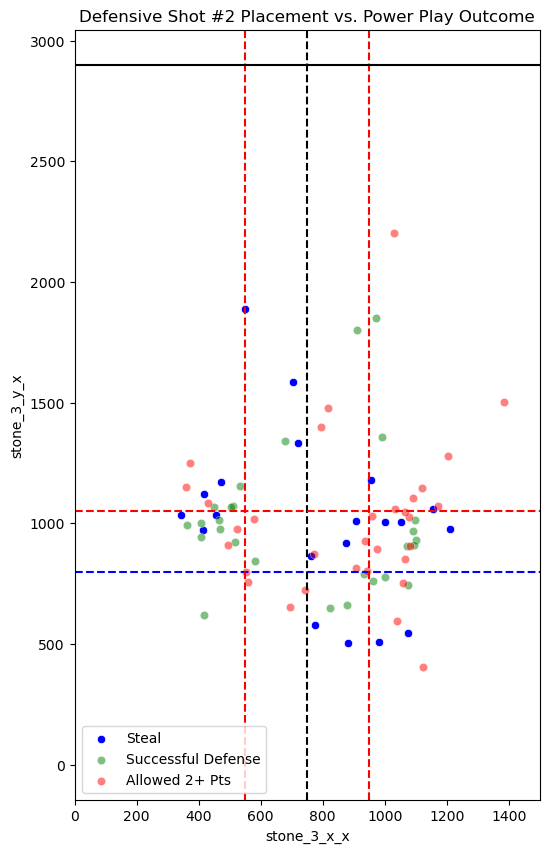

In [40]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x']== 'Steal (Best)'],
    x='stone_3_x_x', y='stone_3_y_x', color='blue', label='Steal', marker='o'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x'].isin(['Force (Good)'])],
    x='stone_3_x_x', y='stone_3_y_x', color='green', alpha=0.5, label='Successful Defense', marker='o'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x'] == 'Failure (Bad)'],
    x='stone_3_x_x', y='stone_3_y_x', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='o'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #2 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on the Y-axis data
plt.show()

In [41]:
success_rate = follow_up_shots['Defense_Outcome_x'].value_counts(normalize=True)
print('overall outside zone shot 1')
print(len(follow_up_shots))
print(success_rate)

overall outside zone shot 1
81
Failure (Bad)    0.419753
Force (Good)     0.333333
Steal (Best)     0.246914
Name: Defense_Outcome_x, dtype: float64


In [42]:
zone_again = follow_up_shots[(~follow_up_shots['stone_3_x_x'].between(550, 950)) & (follow_up_shots['stone_3_y_x'].between(750, 1050))]
zone_again_rate = zone_again['Defense_Outcome_x'].value_counts(normalize=True)
print('outside zone again')
print(len(zone_again))
print(zone_again_rate)

outside zone again
28
Force (Good)     0.464286
Failure (Bad)    0.321429
Steal (Best)     0.214286
Name: Defense_Outcome_x, dtype: float64


In [43]:
outside = follow_up_shots[~follow_up_shots['stone_3_x_x'].between(550, 950)]
outside_rate = outside['Defense_Outcome_x'].value_counts(normalize=True)
print('outside again general')
print(len(outside))
print(outside_rate)

outside again general
57
Failure (Bad)    0.403509
Force (Good)     0.368421
Steal (Best)     0.228070
Name: Defense_Outcome_x, dtype: float64


In [44]:
center = follow_up_shots[follow_up_shots['stone_3_x_x'].between(550, 950)]
center_rate = center['Defense_Outcome_x'].value_counts(normalize=True)
print('center column')
print(len(center))
print(center_rate)

center column
24
Failure (Bad)    0.458333
Steal (Best)     0.291667
Force (Good)     0.250000
Name: Defense_Outcome_x, dtype: float64


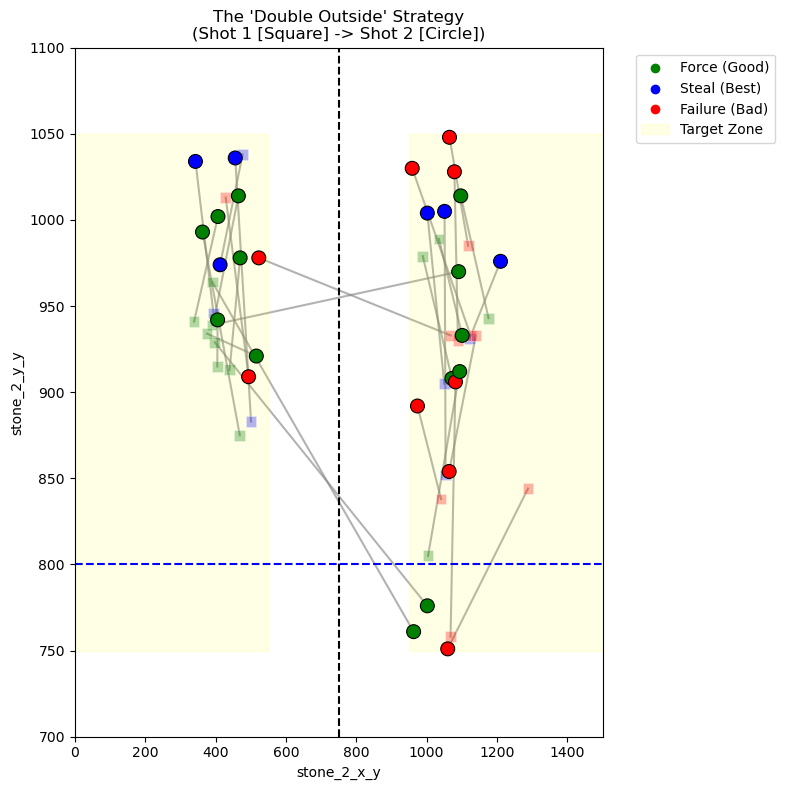

In [45]:
# Filter for the "Double Outside" sequence: 
# Shot 1 (Stone 2) AND Shot 2 (Stone 3) are both in the "Outside Edge" zone.
# Zone: x < 550 OR x > 950, AND y between 750 and 1050.
def is_in_zone(df, x_col, y_col):
    return ( (df[x_col] < 550) | (df[x_col] > 950) ) & (df[y_col] > 750) & (df[y_col] < 1050)

double_outside_df = follow_up_shots[
    is_in_zone(follow_up_shots, 'stone_2_x_y', 'stone_2_y_y') & 
    is_in_zone(follow_up_shots, 'stone_3_x_x', 'stone_3_y_x')
].copy()

plt.figure(figsize=(8, 8))

# Define Colors
colors = {'Steal (Best)': 'blue', 'Force (Good)': 'green', 'Failure (Bad)': 'red'}

# 1. Draw Lines connecting Shot 1 -> Shot 2
# This visualizes the "Interaction" (Stacking, Freezing, etc.)
for idx, row in double_outside_df.iterrows():
    outcome = row['Defense_Outcome_x']
    if outcome in colors: # Safety check
        plt.plot([row['stone_2_x_y'], row['stone_3_x_x']], 
                 [row['stone_2_y_y'], row['stone_3_y_x']], 
                 color='gray', alpha=0.6, zorder=1)

# 2. Plot Shot 1 (Stone 2) - Faded Squares
sns.scatterplot(
    data=double_outside_df,
    x='stone_2_x_y', y='stone_2_y_y', hue='Defense_Outcome_x', palette=colors,
    marker='s', s=60, alpha=0.3, legend=False, zorder=2
)

# 3. Plot Shot 2 (Stone 3) - Solid Circles (The "Double Down" move)
sns.scatterplot(
    data=double_outside_df,
    x='stone_3_x_x', y='stone_3_y_x', hue='Defense_Outcome_x', palette=colors,
    marker='o', s=100, edgecolor='black', zorder=3
)

# --- Context & Markings ---
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button Line

# Highlight the Strategic "Outside Zones"
plt.fill_between([0, 550], 750, 1050, color='yellow', alpha=0.1, label='Target Zone')
plt.fill_between([950, 1500], 750, 1050, color='yellow', alpha=0.1)

plt.xlim(0, 1500)
plt.ylim(700, 1100) # Zoom in to the relevant guard/house area
plt.title("The 'Double Outside' Strategy\n(Shot 1 [Square] -> Shot 2 [Circle])")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

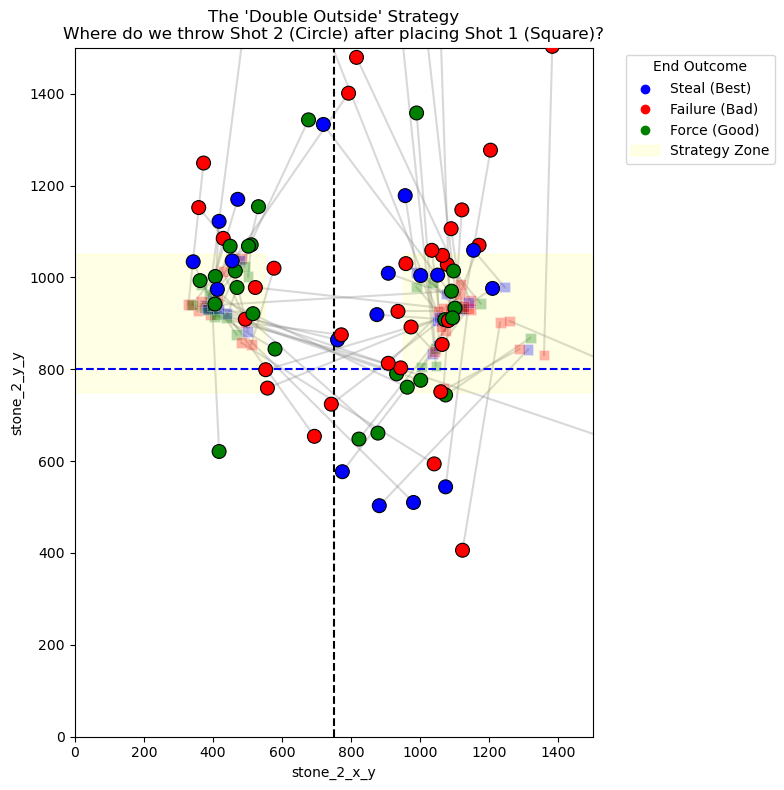

In [46]:
# We use the 'follow_up_shots' dataframe
# Mapping the 'Ugly' Columns to meaningful variables:
# Shot 1 (Past) = _y suffix (from curious_zones) -> Stone 2 was the active rock
# Shot 2 (Present) = _x suffix (from temp_df) -> Stone 3 is the active rock

# Define the coordinates
# Origin of the strategy (where we put the first one)
shot_1_x = follow_up_shots['stone_2_x_y']
shot_1_y = follow_up_shots['stone_2_y_y']

# Execution of the follow-up (where we put the second one)
shot_2_x = follow_up_shots['stone_3_x_x']
shot_2_y = follow_up_shots['stone_3_y_x']

# Outcome (Result of the End)
outcomes = follow_up_shots['Defense_Outcome_x']

plt.figure(figsize=(8, 8))

# Define Colors
colors = {'Steal (Best)': 'blue', 'Force (Good)': 'green', 'Failure (Bad)': 'red'}

# 1. Draw Lines: Connect the STRATEGY (Shot 1 Location -> Shot 2 Location)
# This shows the "deltas" - are you playing tight to the first stone?
for i in range(len(follow_up_shots)):
    outcome = outcomes.iloc[i]
    if outcome in colors:
        plt.plot([shot_1_x.iloc[i], shot_2_x.iloc[i]], 
                 [shot_1_y.iloc[i], shot_2_y.iloc[i]], 
                 color='gray', alpha=0.3, zorder=1)

# 2. Plot Shot 1 (The Setup) - Faded Squares
# Uses _y columns
sns.scatterplot(
    x=shot_1_x, y=shot_1_y, hue=outcomes, palette=colors,
    marker='s', s=60, alpha=0.3, legend=False, zorder=2
)

# 3. Plot Shot 2 (The Follow-up) - Solid Circles
# Uses _x columns
sns.scatterplot(
    x=shot_2_x, y=shot_2_y, hue=outcomes, palette=colors,
    marker='o', s=100, edgecolor='black', zorder=3
)

# --- Context & Markings ---
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button

# Highlight the "Outside Edge" Zone
plt.fill_between([0, 550], 750, 1050, color='yellow', alpha=0.1, label='Strategy Zone')
plt.fill_between([950, 1500], 750, 1050, color='yellow', alpha=0.1)

plt.xlim(0, 1500)
plt.ylim(0, 1500)
plt.title("The 'Double Outside' Strategy\nWhere do we throw Shot 2 (Circle) after placing Shot 1 (Square)?")
plt.legend(title='End Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [47]:
# Load Data
ends_df = pd.read_csv('./curling_database/ends.csv')
stones_df = pd.read_csv('./curling_database/stones.csv')

# 1. Calculate Running Scores
# Sort to ensure ends are in order
ends_df = ends_df.sort_values(['CompetitionID', 'SessionID', 'GameID', 'TeamID', 'EndID'])

# Group by Team and Game to calculate cumulative score
# .shift(1) ensures we get the score *entering* the end, not the result *of* the end
ends_df['PreEnd_TeamScore'] = ends_df.groupby(['CompetitionID', 'SessionID', 'GameID', 'TeamID'])['Result'].transform(lambda x: x.cumsum().shift(1)).fillna(0)
print(ends_df.columns)

pp_lookup = ends_df.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID'])['PowerPlay'].max().reset_index()
# 2. Identify "Defense" vs "Offense" Score for the Shot 7 Thrower
# Filter Stones for the "Defensive Shot #1" (ShotID 7)
defense_shots = stones_df[stones_df['ShotID'] == 7].copy()

# Merge Defense Shot with the Score of the team throwing it
defense_context = pd.merge(
    defense_shots, 
    ends_df[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID', 'PreEnd_TeamScore']], 
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID'],
    how='left'
)
defense_context.rename(columns={'PreEnd_TeamScore': 'Defense_Score'}, inplace=True)

# 3. Get the Opponent's Score
# We need the score of the team that does NOT match the Shot 7 TeamID for that same end
opponent_scores = ends_df.copy()
opponent_scores.rename(columns={'TeamID': 'OpponentID', 'PreEnd_TeamScore': 'Offense_Score', 'Result': 'Offense_Points'}, inplace=True)

# Merge again, but this time join on Game/End but ensure TeamID != OpponentID
# A cleaner way is to merge on Game/End and then filter out the rows where TeamID match
full_context = pd.merge(
    defense_context,
    opponent_scores[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'OpponentID', 'Offense_Score', 'Offense_Points']],
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID'],
    how='left'
)
full_context.rename(columns={'Result': 'Defense_Points'}, inplace=True)

# Filter out self-matches (ensure we got the OTHER team's score)
full_context = full_context[full_context['TeamID'] != full_context['OpponentID']]

# 4. Calculate Differential
# Diff > 0 means Defense is WINNING. Diff < 0 means Defense is LOSING.
full_context['Score_Diff'] = full_context['Defense_Score'] - full_context['Offense_Score']

full_context = pd.merge(
    full_context,
    pp_lookup,
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID'],
    how='left'
)
# 5. Define Context Buckets
def assign_context(diff):
    if diff <= -2:
        return 'Desperate (Down 2+)'
    elif diff >= 1:
        return 'Protecting Lead (Up 1+)'
    else:
        return 'Neutral / Close'

full_context['Game_Context'] = full_context['Score_Diff'].apply(assign_context)
print(full_context.head(20))
# Check the counts to see if we have enough data
print(full_context['Game_Context'].value_counts())

Index(['CompetitionID', 'SessionID', 'GameID', 'TeamID', 'EndID', 'Result',
       'PowerPlay', 'PreEnd_TeamScore'],
      dtype='object')
    CompetitionID  SessionID  GameID  EndID  ShotID  TeamID  PlayerID  Task  \
0               0          1       1      1       7      19         1     0   
1               0          1       1      2       7      27         1     0   
2               0          1       1      3       7      19         1     0   
3               0          1       1      4       7      27         1     0   
4               0          1       1      5       7      19         1     0   
5               0          1       1      6       7      19         1     0   
6               0          1       1      7       7      27         1     0   
7               0          1       1      8       7      27         1     0   
8               0          1       2      1       7      20         1     0   
9               0          1       2      2       7      46         1  

In [48]:
defense_results = ends_df[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID', 'Result']].copy()
full_context = pd.merge(
    full_context,
    defense_results,
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID'],
    how='left'
)
full_context.rename(columns={'Result': 'Defense_Points'}, inplace=True)
full_context.columns

Index(['CompetitionID', 'SessionID', 'GameID', 'EndID', 'ShotID', 'TeamID',
       'PlayerID', 'Task', 'Handle', 'Points', 'TimeOut', 'stone_1_x',
       'stone_1_y', 'stone_2_x', 'stone_2_y', 'stone_3_x', 'stone_3_y',
       'stone_4_x', 'stone_4_y', 'stone_5_x', 'stone_5_y', 'stone_6_x',
       'stone_6_y', 'stone_7_x', 'stone_7_y', 'stone_8_x', 'stone_8_y',
       'stone_9_x', 'stone_9_y', 'stone_10_x', 'stone_10_y', 'stone_11_x',
       'stone_11_y', 'stone_12_x', 'stone_12_y', 'Defense_Score', 'OpponentID',
       'Offense_Score', 'Offense_Points', 'Score_Diff', 'PowerPlay',
       'Game_Context', 'Defense_Points'],
      dtype='object')

In [49]:
def assign_defense_outcome(row):
    d_pts = row['Defense_Points']
    o_pts = row['Offense_Points']
    
    # Error handling for NaNs or Weird Data
    if pd.isna(d_pts) or pd.isna(o_pts):
        return None 
        
    # Logic
    if d_pts > 0:
        return 'Steal (Best)'
    elif o_pts > 0:
        if o_pts == 1:
            return 'Force (Good)'
        else:
            return 'Failure (Bad)'
    else:
        return 'Steal (Best)' # Blank End = Defense keeps Hammer (Good)

In [50]:
print(full_context['Defense_Points'].value_counts())
print(full_context['Offense_Points'].value_counts())
full_context = full_context.dropna(subset=['Defense_Points', 'Offense_Points'])
power_play_defense = full_context[full_context['PowerPlay'] > 0].copy()
power_play_defense['Defense_Outcome'] = power_play_defense.apply(assign_defense_outcome, axis=1)
print("Outcome Distribution:")
print(power_play_defense['Defense_Outcome'].value_counts(normalize=True))
print(len(power_play_defense))
print("Power Play Ends available for analysis:")
print(power_play_defense['Game_Context'].value_counts())

0    1819
1     528
2     167
9      60
3      55
4       7
5       1
Name: Defense_Points, dtype: int64
1    911
0    763
2    544
3    255
4     80
9     60
5     22
6      2
Name: Offense_Points, dtype: int64
Outcome Distribution:
Failure (Bad)    0.449833
Force (Good)     0.326087
Steal (Best)     0.224080
Name: Defense_Outcome, dtype: float64
598
Power Play Ends available for analysis:
Protecting Lead (Up 1+)    376
Neutral / Close            136
Desperate (Down 2+)         86
Name: Game_Context, dtype: int64


In [51]:
power_play_defense.columns

Index(['CompetitionID', 'SessionID', 'GameID', 'EndID', 'ShotID', 'TeamID',
       'PlayerID', 'Task', 'Handle', 'Points', 'TimeOut', 'stone_1_x',
       'stone_1_y', 'stone_2_x', 'stone_2_y', 'stone_3_x', 'stone_3_y',
       'stone_4_x', 'stone_4_y', 'stone_5_x', 'stone_5_y', 'stone_6_x',
       'stone_6_y', 'stone_7_x', 'stone_7_y', 'stone_8_x', 'stone_8_y',
       'stone_9_x', 'stone_9_y', 'stone_10_x', 'stone_10_y', 'stone_11_x',
       'stone_11_y', 'stone_12_x', 'stone_12_y', 'Defense_Score', 'OpponentID',
       'Offense_Score', 'Offense_Points', 'Score_Diff', 'PowerPlay',
       'Game_Context', 'Defense_Points', 'Defense_Outcome'],
      dtype='object')

In [52]:
# Define "Game Phase" (Early vs. Late)
def assign_phase(end_id):
    if end_id <= 5:
        return 'Early Game (Ends 1-5)'
    else:
        return 'Late Game (Ends 6-8)'

In [53]:
strat_edge = power_play_defense[
    (((power_play_defense['stone_2_x'] < 550) | (power_play_defense['stone_2_x'] > 950)) & 
    ((power_play_defense['stone_2_y'] > 750) & (power_play_defense['stone_2_y'] < 1050))) |
    (((power_play_defense['stone_8_x'] < 550) | (power_play_defense['stone_8_x'] > 950)) & 
    ((power_play_defense['stone_8_y'] > 750) & (power_play_defense['stone_8_y'] < 1050)))
]
strat_edge['Game_Phase'] = strat_edge['EndID'].apply(assign_phase)

/var/folders/8q/pd8bhfh923x7_5hc541qy_8c0000gn/T/ipykernel_4280/717050035.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_edge['Game_Phase'] = strat_edge['EndID'].apply(assign_phase)


In [54]:
strat_center = power_play_defense[
    ((power_play_defense['stone_2_x'] > 650) & (power_play_defense['stone_2_x'] < 850) &
    (power_play_defense['stone_2_y'] > 600) & (power_play_defense['stone_2_y'] < 1000)) |
    ((power_play_defense['stone_8_x'] > 650) & (power_play_defense['stone_8_x'] < 850) &
    (power_play_defense['stone_8_y'] > 600) & (power_play_defense['stone_8_y'] < 1000))
]
strat_center['Game_Phase'] = strat_center['EndID'].apply(assign_phase)

/var/folders/8q/pd8bhfh923x7_5hc541qy_8c0000gn/T/ipykernel_4280/3730888432.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_center['Game_Phase'] = strat_center['EndID'].apply(assign_phase)


In [55]:
strat_center.columns

Index(['CompetitionID', 'SessionID', 'GameID', 'EndID', 'ShotID', 'TeamID',
       'PlayerID', 'Task', 'Handle', 'Points', 'TimeOut', 'stone_1_x',
       'stone_1_y', 'stone_2_x', 'stone_2_y', 'stone_3_x', 'stone_3_y',
       'stone_4_x', 'stone_4_y', 'stone_5_x', 'stone_5_y', 'stone_6_x',
       'stone_6_y', 'stone_7_x', 'stone_7_y', 'stone_8_x', 'stone_8_y',
       'stone_9_x', 'stone_9_y', 'stone_10_x', 'stone_10_y', 'stone_11_x',
       'stone_11_y', 'stone_12_x', 'stone_12_y', 'Defense_Score', 'OpponentID',
       'Offense_Score', 'Offense_Points', 'Score_Diff', 'PowerPlay',
       'Game_Context', 'Defense_Points', 'Defense_Outcome', 'Game_Phase'],
      dtype='object')

In [56]:
baseline_outcomes = power_play_defense.groupby('Game_Context')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0)

print("==========================================")
print("     BASELINE: ALL SHOT 7 OUTCOMES       ")
print("==========================================\n")
print(baseline_outcomes)

     BASELINE: ALL SHOT 7 OUTCOMES       

Defense_Outcome          Failure (Bad)  Force (Good)  Steal (Best)
Game_Context                                                      
Desperate (Down 2+)           0.337209      0.383721      0.279070
Neutral / Close               0.470588      0.286765      0.242647
Protecting Lead (Up 1+)       0.468085      0.327128      0.204787


In [57]:
print("==========================================")
print("     ANALYSIS 1: IMPACT OF SCORE      ")
print("==========================================\n")

print(">>> STRATEGY A: OUTSIDE EDGE (Control) by Score Context")
# We look for Low Failure Rates here (Safety)
print(strat_edge.groupby('Game_Context')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

print("\n>>> STRATEGY B: CENTER DRAW (Chaos) by Score Context")
# We look for High Steal Rates here (Desperation)
print(strat_center.groupby('Game_Context')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))


print("\n\n==========================================")
print("     ANALYSIS 2: IMPACT OF TIMING      ")
print("==========================================\n")

print(">>> STRATEGY A: OUTSIDE EDGE (Control) by Game Phase")
print(strat_edge.groupby('Game_Phase')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

print("\n>>> STRATEGY B: CENTER DRAW (Chaos) by Game Phase")
print(strat_center.groupby('Game_Phase')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

     ANALYSIS 1: IMPACT OF SCORE      

>>> STRATEGY A: OUTSIDE EDGE (Control) by Score Context
Defense_Outcome          Failure (Bad)  Force (Good)  Steal (Best)
Game_Context                                                      
Desperate (Down 2+)           0.083333      0.583333      0.333333
Neutral / Close               0.500000      0.239130      0.260870
Protecting Lead (Up 1+)       0.397959      0.357143      0.244898

>>> STRATEGY B: CENTER DRAW (Chaos) by Score Context
Defense_Outcome          Failure (Bad)  Force (Good)  Steal (Best)
Game_Context                                                      
Desperate (Down 2+)           0.500000      0.500000      0.000000
Neutral / Close               0.428571      0.142857      0.428571
Protecting Lead (Up 1+)       0.714286      0.285714      0.000000


     ANALYSIS 2: IMPACT OF TIMING      

>>> STRATEGY A: OUTSIDE EDGE (Control) by Game Phase
Defense_Outcome        Failure (Bad)  Force (Good)  Steal (Best)
Game_Phase         

In [58]:
# Filter for the two most common defensive tasks
pp_raises = power_play_defense[power_play_defense['Task'] == 3].copy()
pp_draws = power_play_defense[power_play_defense['Task'] == 0].copy()

print("\n==========================================")
print("   SHOT TYPE COMPARISON: RAISE vs DRAW    ")
print("==========================================\n")

print(">>> RAISE (Task 3) Outcomes by Context:")
print(pp_raises.groupby('Game_Context')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

print("\n>>> DRAW (Task 0) Outcomes by Context:")
print(pp_draws.groupby('Game_Context')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))


   SHOT TYPE COMPARISON: RAISE vs DRAW    

>>> RAISE (Task 3) Outcomes by Context:
Defense_Outcome          Failure (Bad)  Force (Good)  Steal (Best)
Game_Context                                                      
Neutral / Close               0.333333      0.000000      0.666667
Protecting Lead (Up 1+)       0.425287      0.356322      0.218391

>>> DRAW (Task 0) Outcomes by Context:
Defense_Outcome          Failure (Bad)  Force (Good)  Steal (Best)
Game_Context                                                      
Desperate (Down 2+)           0.185185      0.481481      0.333333
Neutral / Close               0.486486      0.243243      0.270270
Protecting Lead (Up 1+)       0.469027      0.336283      0.194690


In [59]:
# Look at Raises that scored 0-1 points (poor execution) vs those that scored 3-4 (good execution)
pp_raises['Execution_Quality'] = pp_raises['Points'].apply(lambda x: 'Low (0-2)' if x <= 2 else 'High (3-4)')

print("\n>>> RAISE OUTCOMES BY EXECUTION QUALITY")
print(pp_raises.groupby('Execution_Quality')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))


>>> RAISE OUTCOMES BY EXECUTION QUALITY
Defense_Outcome    Failure (Bad)  Force (Good)  Steal (Best)
Execution_Quality                                           
High (3-4)              0.424242      0.333333      0.242424
Low (0-2)               0.416667      0.375000      0.208333


In [60]:
# Create interaction groups
power_play_defense['In_Edge_Zone'] = (((power_play_defense['stone_2_x'] < 550) | (power_play_defense['stone_2_x'] > 950)) & \
                                     ((power_play_defense['stone_2_y'] > 750) & (power_play_defense['stone_2_y'] < 1050))) | \
                                    (((power_play_defense['stone_8_x'] < 550) | (power_play_defense['stone_8_x'] > 950)) & \
                                     ((power_play_defense['stone_8_y'] > 750) & (power_play_defense['stone_8_y'] < 1050)))

print("==========================================")
print("   ZONE vs. TASK: IS IT LOCATION OR SHOT? ")
print("==========================================\n")

# Compare Draw (0) in-zone vs out-of-zone
draws = power_play_defense[power_play_defense['Task'] == 0]
print(">>> DRAW (Task 0) Outcomes by Zone:")
print(draws.groupby('In_Edge_Zone')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

# Compare Raise (3) in-zone vs out-of-zone
raises = power_play_defense[power_play_defense['Task'] == 3]
print("\n>>> RAISE (Task 3) Outcomes by Zone:")
print(raises.groupby('In_Edge_Zone')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

   ZONE vs. TASK: IS IT LOCATION OR SHOT? 

>>> DRAW (Task 0) Outcomes by Zone:
Defense_Outcome  Failure (Bad)  Force (Good)  Steal (Best)
In_Edge_Zone                                              
False                 0.493827      0.308642      0.197531
True                  0.406015      0.330827      0.263158

>>> RAISE (Task 3) Outcomes by Zone:
Defense_Outcome  Failure (Bad)  Force (Good)  Steal (Best)
In_Edge_Zone                                              
False                 0.419753      0.333333      0.246914
True                  0.444444      0.444444      0.111111


In [61]:
print("\n==========================================")
print("      SECONDARY SHOT TYPE ANALYSIS        ")
print("==========================================\n")

# Filter for the 'bench' shots
bench_tasks = [0, 1, 2, 3, 4] # Front, Guard, Wick
secondary_shots = power_play_defense[power_play_defense['Task'].isin(bench_tasks)].copy()

# Map the names for readability
task_map = {0: "Draw", 1: 'Front', 2: 'Guard', 3: "Raise", 4: 'Wick'}
secondary_shots['Task_Name'] = secondary_shots['Task'].map(task_map)

print(">>> Outcomes for Secondary Opening Shots:")
print(secondary_shots.groupby('Task_Name')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))


      SECONDARY SHOT TYPE ANALYSIS        

>>> Outcomes for Secondary Opening Shots:
Defense_Outcome  Failure (Bad)  Force (Good)  Steal (Best)
Task_Name                                                 
Draw                  0.439252      0.322430      0.238318
Front                 0.435294      0.305882      0.258824
Guard                 0.500000      0.357143      0.142857
Raise                 0.422222      0.344444      0.233333
Wick                  0.465839      0.329193      0.204969


In [62]:
# Segment Fronts by execution
pp_fronts = power_play_defense[power_play_defense['Task'] == 1].copy()
pp_fronts['Execution_Quality'] = pp_fronts['Points'].apply(lambda x: 'Low (0-2)' if x <= 2 else 'High (3-4)')

print("==========================================")
print("   FRONT (Task 1): EXECUTION vs OUTCOME   ")
print("==========================================\n")
print(pp_fronts.groupby('Execution_Quality')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))

   FRONT (Task 1): EXECUTION vs OUTCOME   

Defense_Outcome    Failure (Bad)  Force (Good)  Steal (Best)
Execution_Quality                                           
High (3-4)              0.417722      0.316456      0.265823
Low (0-2)               0.666667      0.166667      0.166667


In [63]:
pp_fronts['Execution_Quality'].value_counts()

High (3-4)    79
Low (0-2)      6
Name: Execution_Quality, dtype: int64

In [64]:
# Segment Wicks by execution
pp_wicks = power_play_defense[power_play_defense['Task'] == 4].copy()
pp_wicks['Execution_Quality'] = pp_wicks['Points'].apply(lambda x: 'Low (0-2)' if x <= 2 else 'High (3-4)')

print("\n==========================================")
print("    WICK (Task 4): EXECUTION vs OUTCOME   ")
print("==========================================\n")
print(pp_wicks.groupby('Execution_Quality')['Defense_Outcome'].value_counts(normalize=True).unstack().fillna(0))


    WICK (Task 4): EXECUTION vs OUTCOME   

Defense_Outcome    Failure (Bad)  Force (Good)  Steal (Best)
Execution_Quality                                           
High (3-4)              0.463158      0.315789      0.221053
Low (0-2)               0.469697      0.348485      0.181818


In [65]:
pp_wicks['Execution_Quality'].value_counts()

High (3-4)    95
Low (0-2)     66
Name: Execution_Quality, dtype: int64

# Moving to Offense

| Scenario | Board Configuration | Objective of Analysis |
|----------|---------------------|----------------------|
| The "Edge Pressure" | stone_2 is in the Edge Zones (x < 550 or x > 950, y between 750-1050). | Determine how to beat the "Optimal Defense" we identified. |
| The "Center Clutter" | stone_2 is in the True Center House (x: 650-850, y: 700-1000). | How to punish a defender who ignores the corner and clogs the button. |
| The "High Guard" | stone_2 is a high center guard (x: 650-850, y > 1200). | How to maximize scoring when the defender "misses" into a guard. |
| The "Edge Disruption" | stone_1 or stone_2 are in the Edge Guard zones (x < 550 or x > 950, y > 1100). | Response to successful or partially successful raises and wicks. |
| The "Clean House" | stone_2 is out of play (4095) or a complete whiff. | The "Ideal Power Play": What is the highest-scoring sequence from a blank slate? |

In [66]:
# 1. Define Offensive Scenarios based on Stone Placement
def categorize_board_state(row):
    s1x, s1y = row['stone_1_x'], row['stone_1_y']
    s2x, s2y = row['stone_2_x'], row['stone_2_y']
    
    # Whiff / Out of Play
    if s2x == 4095 or s2x == 0:
        return 'Clean House (Whiff)'
    
    # Edge Zone (The "Good" Defense)
    if ((s2x < 550) or (s2x > 950)) and (750 < s2y < 1050):
        return 'Edge Pressure (Optimum)'
    
    # True Center House
    if (650 < s2x < 850) and (600 < s2y < 1000):
        return 'True Center Clutter'
        
    # High Center Guard (The "Missed Draw/Front")
    if (650 < s2x < 850) and (s2y > 1100):
        return 'High Center Guard'
        
    # Edge Guards (Wick/Raise outcomes)
    if ((s1x < 550) or (s1x > 950) or (s2x < 550) or (s2x > 950)) and (s1y > 1100 or s2y > 1100):
        return 'Edge Guard Disruption'
        
    return 'Other/Weird'

# 2. Prepare Offensive DataFrame
# Filter for ShotID 8 (The Hammer Team's first response)
offensive_shots = stones_df[stones_df['ShotID'] == 8].copy()

# 2. Drop stone position columns from offensive_shots 
# We only want the stone positions FROM the power_play_defense dataframe 
# because those represent the board state AFTER the defender's first shot.
cols_to_drop = [col for col in offensive_shots.columns if 'stone_' in col]
offensive_shots_clean = offensive_shots.drop(columns=cols_to_drop)

# Merge with the outcome and board state
offense_analysis = pd.merge(offensive_shots_clean, power_play_defense[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Defense_Outcome', 'Offense_Points', 'stone_1_x', 'stone_1_y', 'stone_2_x', 'stone_2_y']], on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
offense_analysis['Board_State'] = offense_analysis.apply(categorize_board_state, axis=1)

# 3. Analyze Outcomes: What is the best response to 'Edge Pressure'?
# We want to see which Task (Shot 8) results in the highest "Offense_Points" (3+)
print(">>> BEST OFFENSIVE RESPONSES BY BOARD STATE")
print(offense_analysis.groupby(['Board_State', 'Task'])['Offense_Points'].mean().unstack().fillna(0))

>>> BEST OFFENSIVE RESPONSES BY BOARD STATE
Task                           0    1         2         3         4    5   \
Board_State                                                                 
Clean House (Whiff)      1.675781  0.5  1.150943  1.952381  1.884615  1.0   
Edge Guard Disruption    1.530303  2.0  1.307692  0.000000  0.500000  0.0   
Edge Pressure (Optimum)  1.423729  0.0  0.000000  1.833333  1.000000  0.0   
High Center Guard        2.075000  0.0  1.000000  1.000000  2.058824  0.0   
True Center Clutter      2.333333  0.0  0.000000  0.000000  1.000000  0.0   

Task                      6    8    11  
Board_State                             
Clean House (Whiff)      0.0  1.0  1.0  
Edge Guard Disruption    0.0  0.0  0.0  
Edge Pressure (Optimum)  9.0  0.0  0.0  
High Center Guard        2.0  0.0  0.0  
True Center Clutter      0.0  0.0  0.0  


In [67]:
hammer_lookup = ends_df[ends_df['PowerPlay'] > 0][['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID']].copy()
hammer_lookup.rename(columns={'TeamID': 'Hammer_TeamID'}, inplace=True)

offense_shots = stones_df[stones_df['ShotID'] == 8].copy()
offense_shots = pd.merge(offense_shots, hammer_lookup, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'], how='left')

def get_correct_stones(row):
    # Case A: Hammer team threw the second set of stones (7-12)
    # Their first thrown is Stone 8. The Defender's first thrown was Stone 2.
    if row['TeamID'] == row['Hammer_TeamID']:
        return pd.Series({
            'def_x': row['stone_2_x'], 'def_y': row['stone_2_y'],
            'off_x': row['stone_8_x'], 'off_y': row['stone_8_y']
        })
    # Case B: Hammer team threw the first set of stones (1-6)
    # Their first thrown is Stone 2. The Defender's first thrown was Stone 8.
    else:
        return pd.Series({
            'def_x': row['stone_8_x'], 'def_y': row['stone_8_y'],
            'off_x': row['stone_2_x'], 'off_y': row['stone_2_y']
        })
        
# Apply the logic to create clear spatial columns
offense_shots[['def_x', 'def_y', 'off_x', 'off_y']] = offense_shots.apply(get_correct_stones, axis=1)

In [68]:
def categorize_offensive_landing(row):
    x, y = row['off_x'], row['off_y']
    if x == 4095 or x == 0: return 'Out of Play / Whiff'
    
    # Zone: The Button (Matching the center clutter)
    if (650 < x < 850) and (650 < y < 950):
        return 'Button / Tee Line'
    
    # Zone: The Opposite Edge (Splitting the house)
    # This identifies if you stayed away from the defender
    if (x < 550 or x > 950) and (750 < y < 1050):
        return 'Opposite Edge'
        
    return 'General House'

offense_shots['Landing_Zone'] = offense_shots.apply(categorize_offensive_landing, axis=1)

# Now merge with points/outcomes
final_offense = pd.merge(
    offense_shots, 
    power_play_defense[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Offense_Points']], 
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID']
)

print(">>> OFFENSIVE SUCCESS BY LANDING ZONE (Task 0 - Draws)")
print(final_offense[final_offense['Task'] == 0].groupby('Landing_Zone')['Offense_Points'].mean())

>>> OFFENSIVE SUCCESS BY LANDING ZONE (Task 0 - Draws)
Landing_Zone
Button / Tee Line      1.222222
General House          1.678899
Opposite Edge          1.657895
Out of Play / Whiff    1.745098
Name: Offense_Points, dtype: float64


In [69]:
# 1. First, we need to bring the Board_State (from the defender's shot) 
# into our new perspectivized offense_shots dataframe.
final_offense = pd.merge(
    offense_shots, 
    offense_analysis[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Board_State', 'Offense_Points']], 
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID']
)

# 2. Filter for Draws (Task 0) to compare placement strategy
off_draws = final_offense[final_offense['Task'] == 0]

print("==========================================================")
print("   OFFENSIVE DRAW STRATEGY: LANDING ZONE BY BOARD STATE   ")
print("==========================================================\n")

# This creates a pivot table showing average points for each combination
# It answers: "Given [Board State], where should I land my Draw?"
draw_strategy_matrix = off_draws.groupby(['Board_State', 'Landing_Zone'])['Offense_Points'].mean().unstack().fillna(0)

print(draw_strategy_matrix)

# 3. Optional: Check Sample Sizes (Important to ensure 1.74 isn't just one end)
print("\n>>> SAMPLE SIZES (Number of Ends):")
print(off_draws.groupby(['Board_State', 'Landing_Zone']).size().unstack().fillna(0))

   OFFENSIVE DRAW STRATEGY: LANDING ZONE BY BOARD STATE   

Landing_Zone             Button / Tee Line  General House  Opposite Edge  \
Board_State                                                                
Clean House (Whiff)               1.166667       1.693431       1.611940   
Edge Guard Disruption             1.500000       1.515152       1.448276   
Edge Pressure (Optimum)           0.000000       1.125000       1.676471   
High Center Guard                 1.000000       2.388889       2.000000   
True Center Clutter               0.000000       2.333333       2.333333   

Landing_Zone             Out of Play / Whiff  
Board_State                                   
Clean House (Whiff)                 1.782609  
Edge Guard Disruption               3.000000  
Edge Pressure (Optimum)             0.000000  
High Center Guard                   0.500000  
True Center Clutter                 0.000000  

>>> SAMPLE SIZES (Number of Ends):
Landing_Zone             Button / Tee Line

In [70]:
# --- 1. IDENTIFY PERSPECTIVE (Who is Offense/Defense) ---

# Find which team called the Power Play in each end
hammer_lookup = ends_df[ends_df['PowerPlay'] > 0][['CompetitionID', 'SessionID', 'GameID', 'EndID', 'TeamID']].copy()
hammer_lookup.rename(columns={'TeamID': 'Hammer_TeamID'}, inplace=True)

# Prepare Shot 8 (Offense's first response)
offense_shots = stones_df[stones_df['ShotID'] == 8].copy()
offense_shots = pd.merge(offense_shots, hammer_lookup, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'], how='left')

# Map the coordinates so 'def' is the defender and 'off' is the hammer team
def get_correct_stones(row):
    if row['TeamID'] == row['Hammer_TeamID']:
        return pd.Series({'def_x': row['stone_2_x'], 'def_y': row['stone_2_y'],
                          'off_x': row['stone_8_x'], 'off_y': row['stone_8_y']})
    else:
        return pd.Series({'def_x': row['stone_8_x'], 'def_y': row['stone_8_y'],
                          'off_x': row['stone_2_x'], 'off_y': row['stone_2_y']})

offense_shots[['def_x', 'def_y', 'off_x', 'off_y']] = offense_shots.apply(get_correct_stones, axis=1)

In [71]:
# --- 2. CATEGORIZE DEFENSIVE BOARD STATE (The Situation) ---

def categorize_board_state(row):
    dx, dy = row['def_x'], row['def_y']
    
    if dx == 4095 or dx == 0: return 'Clean House (Whiff)'
    
    # Edge Zone (The "Good" Defense)
    if ((dx < 550) or (dx > 950)) and (750 < dy < 1050):
        return 'Edge Pressure (Optimum)'
    
    # True Center House
    if (650 < dx < 850) and (600 < dy < 1000):
        return 'True Center Clutter'
        
    # High Center Guard
    if (650 < dx < 850) and (dy > 1100):
        return 'High Center Guard'
        
    return 'Other/Scramble'

offense_shots['Board_State'] = offense_shots.apply(categorize_board_state, axis=1)

In [72]:
# --- 3. CATEGORIZE OFFENSIVE LANDING (The Result) ---

def categorize_offensive_landing(row):
    ox, oy = row['off_x'], row['off_y']
    dx = row['def_x']
    
    if ox == 4095 or ox == 0: return 'Out of Play / Whiff'
    
    # Button Check
    if (650 < ox < 850) and (650 < oy < 950):
        return 'Button'
    
    # "True Split" Check: 
    # Must be in an edge zone AND on the opposite side of the defender
    is_in_edge = ((ox < 550) or (ox > 950)) and (750 < oy < 1050)
    if is_in_edge:
        # Check if they are on different sides of the center line (x=800)
        if (dx < 800 and ox > 800) or (dx > 800 and ox < 800):
            return 'True Split (Opposite Edge)'
        else:
            return 'Same Side Edge'
            
    return 'General House'

offense_shots['Landing_Zone'] = offense_shots.apply(categorize_offensive_landing, axis=1)

In [73]:
# --- 4. MERGE WITH OUTCOMES AND ANALYZE ---

# Bring in the Offense_Points from the existing power_play_defense dataframe
final_offense = pd.merge(
    offense_shots, 
    power_play_defense[['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Offense_Points']], 
    on=['CompetitionID', 'SessionID', 'GameID', 'EndID']
)

In [74]:
# A. The Strategy Call: Which Task works best for each Board State?
print("==========================================")
print("   OFFENSIVE TASK ANALYSIS (BY INTENT)    ")
print("==========================================\n")
task_matrix = final_offense.groupby(['Board_State', 'Task'])['Offense_Points'].mean().unstack().fillna(0)
print(task_matrix)

   OFFENSIVE TASK ANALYSIS (BY INTENT)    

Task                           0    1         2         3         4    5   \
Board_State                                                                 
Clean House (Whiff)      1.620000  1.0  1.105263  1.000000  0.769231  1.0   
Edge Pressure (Optimum)  1.561290  0.0  0.000000  2.047619  1.666667  0.0   
High Center Guard        2.073171  0.0  1.000000  1.000000  2.555556  0.0   
Other/Scramble           1.658537  1.0  1.212766  1.812500  2.190476  0.0   
True Center Clutter      1.900000  0.0  0.000000  1.000000  0.000000  0.0   

Task                      6    8    11  
Board_State                             
Clean House (Whiff)      0.0  1.0  1.0  
Edge Pressure (Optimum)  0.0  0.0  0.0  
High Center Guard        0.0  0.0  0.0  
Other/Scramble           5.5  1.0  0.0  
True Center Clutter      0.0  0.0  0.0  


In [75]:
# B. The Execution Check: When drawing, where is best?
print("\n==========================================")
print("   DRAW ANALYSIS: LANDING ZONE SUCCESS    ")
print("==========================================\n")
draw_matrix = final_offense[final_offense['Task'] == 0].groupby(['Board_State', 'Landing_Zone'])['Offense_Points'].mean().unstack().fillna(0)
print(draw_matrix)


   DRAW ANALYSIS: LANDING ZONE SUCCESS    

Landing_Zone             Button  General House  Out of Play / Whiff  \
Board_State                                                           
Clean House (Whiff)        1.50       1.379310             1.000000   
Edge Pressure (Optimum)    0.00       1.513158             1.750000   
High Center Guard          0.50       2.529412             0.500000   
Other/Scramble             1.75       1.741176             1.884615   
True Center Clutter        0.00       1.818182             1.800000   

Landing_Zone             Same Side Edge  True Split (Opposite Edge)  
Board_State                                                          
Clean House (Whiff)            3.000000                    1.125000  
Edge Pressure (Optimum)        1.578947                    1.800000  
High Center Guard              2.454545                    1.444444  
Other/Scramble                 1.472222                    1.153846  
True Center Clutter            2.3333

In [76]:
# C. Risk Analysis: Whiff rates per task
final_offense['is_whiff'] = (final_offense['Landing_Zone'] == 'Out of Play / Whiff').astype(int)
print("\n==========================================")
print("     RISK ANALYSIS: WHIFF RATE %          ")
print("==========================================\n")
whiff_rates = final_offense.groupby(['Board_State', 'Task'])['is_whiff'].mean().unstack().fillna(0)
print(whiff_rates)


     RISK ANALYSIS: WHIFF RATE %          

Task                           0    1         2    3         4    5    6   \
Board_State                                                                 
Clean House (Whiff)      0.040000  0.0  0.000000  0.0  0.000000  0.0  0.0   
Edge Pressure (Optimum)  0.103226  0.0  0.000000  0.0  0.166667  0.0  0.0   
High Center Guard        0.048780  0.0  0.000000  1.0  0.888889  0.0  0.0   
Other/Scramble           0.158537  0.0  0.361702  0.0  0.190476  0.0  0.5   
True Center Clutter      0.250000  0.0  0.000000  0.0  0.000000  0.0  0.0   

Task                      8    11  
Board_State                        
Clean House (Whiff)      0.0  0.0  
Edge Pressure (Optimum)  0.0  0.0  
High Center Guard        0.0  0.0  
Other/Scramble           0.0  0.0  
True Center Clutter      0.0  0.0  


In [77]:
# D. Execution vs. Outcome Analysis
# 1. Define Execution Buckets
def bucket_execution(pts):
    if pts <= 2: return 'Low (0-2)'
    else: return 'High (3-4)'

final_offense['Exec_Quality'] = final_offense['Points'].apply(bucket_execution)

# 2. Analyze Outcome by Execution and Task
# We want to see: if I "miss" (Low Exec), how many points do I actually lose?
risk_reward_matrix = final_offense.groupby(['Task', 'Exec_Quality'])['Offense_Points'].agg(['mean', 'count']).unstack()

print("==========================================")
print("   OFFENSIVE RISK/REWARD: EXECUTION VS. POINTS   ")
print("==========================================\n")
print(risk_reward_matrix)

# 3. Probability of a "Big End" (3+) vs a "Failure" (0)
# This shows the actual distribution of outcomes based on the call
def get_dist(group):
    total = len(group)
    return pd.Series({
        'Score 0 (Fail)': (group['Offense_Points'] == 0).sum() / total,
        'Score 3+ (Big)': (group['Offense_Points'] >= 3).sum() / total,
        'Avg Score': group['Offense_Points'].mean()
    })

task_distribution = final_offense.groupby('Task').apply(get_dist)

print("\n==========================================")
print("     TASK OUTCOME DISTRIBUTIONS           ")
print("==========================================\n")
print(task_distribution)

   OFFENSIVE RISK/REWARD: EXECUTION VS. POINTS   

                   mean                count          
Exec_Quality High (3-4) Low (0-2) High (3-4) Low (0-2)
Task                                                  
0              1.729107  1.421687      347.0      83.0
1              1.000000       NaN        3.0       NaN
2              1.140351  1.363636       57.0      11.0
3              1.942857  1.285714       35.0       7.0
4              2.272727  1.444444       22.0      27.0
5              1.000000       NaN        1.0       NaN
6              9.000000  2.000000        1.0       1.0
8              1.000000  1.000000        1.0       1.0
11             1.000000       NaN        1.0       NaN

     TASK OUTCOME DISTRIBUTIONS           

      Score 0 (Fail)  Score 3+ (Big)  Avg Score
Task                                           
0           0.209302        0.234884   1.669767
1           0.333333        0.000000   1.000000
2           0.250000        0.088235   1.176471
3   

# Notes overall offense strategy

Pillar 1: The Choice of Intent (Task Selection)
The "Safety" of the Raise (Task 3)

The Data: The Raise has the lowest Failure Rate (Score 0) at only 11.9%, compared to the Draw’s 20.9%.

Insight: In a Power Play, moving any stone (even imperfectly) creates a more favorable board state for the Hammer than missing a draw entirely. It is the "Pro's Choice" for avoiding a blank or a steal.

The "Big End" Ceiling (The Draw vs. The Raise)

The Data: The Draw (Task 0) has a 23.5% probability of scoring 3+ points, whereas the Raise (Task 3) is lower at 19.0%.

Insight: A Draw creates "Split House" complexity—it forces the defender to choose between two scoring threats. A Raise simplifies the house by moving stones, which is better for scoring something but less effective for scoring big.

Pillar 2: Spatial Strategy (The "Duel")
The "True Split" Superiority

The Data: Against Edge Pressure (Optimum Defense), landing a draw on the Opposite Edge (1.80 pts) significantly outperforms the Same Side Edge (1.58 pts) and the General House (1.51 pts).

Insight: Success in the Power Play is driven by the "Width of the Technical Game." If the offense places a stone on the opposite side of the house from the defender, they force the defender to throw a much harder shot to guard both lanes.

The "Button" Matching Trap

The Data: If a defender clogs the True Center House, the offense's best response is to follow them in with a Draw (2.33 pts).

Insight: When a defender abandons the edge to play a "Standard" game, the offense holds a massive technical advantage. The offense should not overcomplicate the end; they should simply out-draw the defender to the pin.

Pillar 3: Execution and Risk Tolerance
The Resilient Floor (Execution vs. Points)

The Data: A "Low Execution" (0–2 pts) Raise yields 1.28 points, while a "Low Execution" Draw yields 1.42 points.

Insight: Unlike the defense (where a "bad" front or guard is catastrophic), offensive misses are less punishing. The Hammer team has enough "board advantage" in a Power Play to recover from a poorly executed first throw, provided the stone stays in play.

The "Whiff" Penalty

The Data: Offensive draws result in a "Whiff/Out of Play" status only ~4-10% of the time, whereas Wicks fail to stay in play nearly 90% of the time when targeting guards.

Insight: Against a Power Play defense, "Shot 1" for the offense is all about establishing a second threat. Any shot that ends up out of play (a through-shot or a missed wick) is a massive win for the defense.

| Scenario | Recommendation | Why? |
|----------|----------------|------|
| Safety First (Avoid 0) | The Raise (Task 3) | Lowest failure rate (11.9%) and high resiliency to poor execution. |
| Chasing a Big End (3+) | The Draw (Task 0) | Highest probability of a 3+ score (23.5%). Must target the "True Split" (Opposite Edge). |
| Against Edge Pressure | The True Split Draw | A Draw to the opposite side averages 1.80 vs. 1.51 for a general draw. |
| High Center Guard | The Draw (Task 0) | Don't be tempted by the Wick (88% whiff rate). Draw behind the guard for a 2.53 point average. |

In [78]:
# Create indicators for Big Scores and Failures
final_offense['is_big_end'] = (final_offense['Offense_Points'] >= 3).astype(int)
final_offense['is_fail_end'] = (final_offense['Offense_Points'] == 0).astype(int)

# Create the pivot tables
ceiling_matrix = final_offense.groupby(['Board_State', 'Task'])['is_big_end'].mean().unstack().fillna(0)
floor_matrix = final_offense.groupby(['Board_State', 'Task'])['is_fail_end'].mean().unstack().fillna(0)

print("==========================================")
print("   OFFENSIVE CEILING: % CHANCE OF 3+      ")
print("==========================================\n")
print(ceiling_matrix)

print("\n==========================================")
print("    OFFENSIVE FLOOR: % CHANCE OF 0       ")
print("==========================================\n")
print(floor_matrix)

   OFFENSIVE CEILING: % CHANCE OF 3+      

Task                           0    1         2         3         4    5   \
Board_State                                                                 
Clean House (Whiff)      0.180000  0.0  0.157895  0.000000  0.000000  0.0   
Edge Pressure (Optimum)  0.232258  0.0  0.000000  0.238095  0.333333  0.0   
High Center Guard        0.365854  0.0  0.000000  0.000000  0.222222  0.0   
Other/Scramble           0.219512  0.0  0.063830  0.187500  0.285714  0.0   
True Center Clutter      0.250000  0.0  0.000000  0.000000  0.000000  0.0   

Task                      6    8    11  
Board_State                             
Clean House (Whiff)      0.0  0.0  0.0  
Edge Pressure (Optimum)  0.0  0.0  0.0  
High Center Guard        0.0  0.0  0.0  
Other/Scramble           0.5  0.0  0.0  
True Center Clutter      0.0  0.0  0.0  

    OFFENSIVE FLOOR: % CHANCE OF 0       

Task                           0    1         2         3         4    5   \
Board_St

# more notes

Defensive Baseline (All Shot 7s)

When a team faces a Power Play, here is their global expectation:

Steal (Best): 20.6%

Force (Good): 32.6%

Failure (Bad): 46.8%

Avg. Points Conceded: ~1.67 points.

Offensive Baseline (All Shot 8s)

When a team calls a Power Play, here is their global expectation:

Big End (3+ Points): 23.1%

Blank/Steal (0 Points): 20.8%

Average Score: 1.67 points.

Part 1: The Defensive Playbook (Shot 7)
The goal of the defense is to minimize the "Power" of the Power Play by forcing a single point or stealing.

1. The Optimal Setup: The Edge Draw

The Finding: Targeting the Outside Edge Zone (House x < 550 or > 950) is the most effective defensive strategy.

The Data: This strategy yields a Failure Rate (2+ points) of only 40.6%, compared to nearly 50% for standard guards or out-of-zone draws.

Desperation Utility: When down by 2+ points, using the Edge strategy results in a staggering 8.3% failure rate, whereas clogging the center results in 50% failure.

2. The "Safety Net" of the Raise (Task 3)

The Finding: The Raise is the most resilient shot type for the defense.

The Data: Low-execution (0-2 pts) and High-execution (3-4 pts) Raises have nearly identical failure rates (~42%).

Insight: Unlike a draw (which must be precise), "bumping" a guard into the house—even poorly—maintains a high defensive floor.

3. Tactics to Avoid

The Guard Trap: Throwing a standard center guard as Shot 7 has a 50% Failure Rate. It is a "punt" that hands control to the offense.

The Wick Trap: Wicks are over-called. They have a high execution failure rate, and even when successful, they result in a 46.3% failure rate.

Part 2: The Offensive Counter-Punch (Shot 8)
The goal of the offense is to maximize the "Big End" (3+ points) while avoiding a waste of the Hammer.

1. The "True Split" Theory

The Finding: Against an optimal defender, the offense must split the house.

The Data: Landing an offensive draw on the Opposite Edge (1.80 pts) significantly outperforms same-side draws (1.58 pts) or general house draws (1.51 pts).

Tactical Advice: Forcing the defender to guard two separate lanes doubles the difficulty of their subsequent shots.

2. Identifying the Ceiling vs. the Floor

The High Ceiling (The Draw): Task 0 has the highest overall probability of a Big End (3+) at 23.5%. This is the choice when you are down in score and need a momentum shift.

The High Floor (The Raise): Task 3 has the lowest Failure Rate (0 points) at 11.9%. Against "Edge Pressure," the Raise drops the chance of a 0-point end to 9.5%. This is the choice when you are tied and need to ensure you at least score 1.

3. Punishing the "Missed" Defense

The High Center Guard: If the defender leaves a high guard, Drawing (Task 0) behind it results in a 36.6% chance of a Big End.

The Center Clutter: If the defender follows the "Standard" game by clogging the center, the offense should out-draw them to the pin, yielding a 1.90 average and the lowest failure rate (10%).

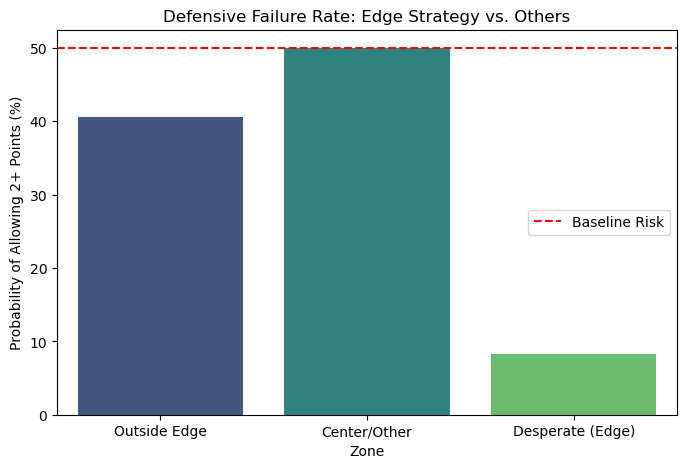

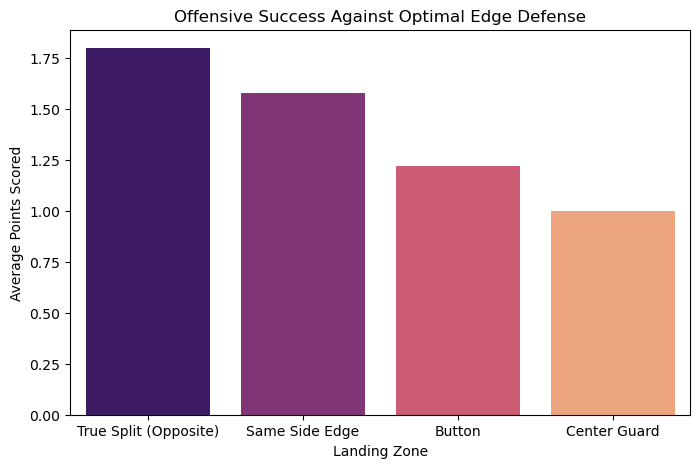

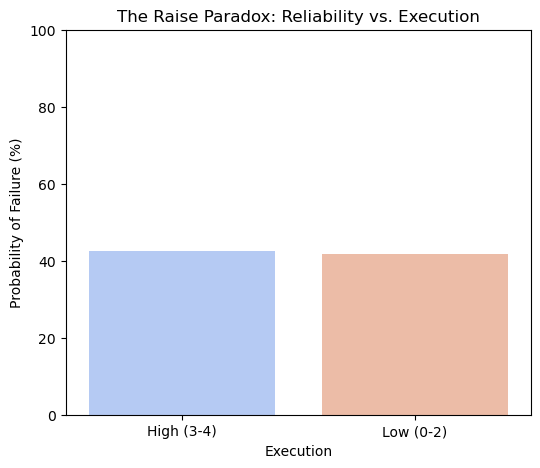

In [79]:
# --- VISUAL 1: The Defensive 'Edge' Advantage ---
# Comparing Failure Rates (2+ points) by Zone
defense_data = {
    'Zone': ['Outside Edge', 'Center/Other', 'Desperate (Edge)'],
    'Failure Rate %': [40.6, 50.0, 8.3]
}
df_def = pd.DataFrame(defense_data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Zone', y='Failure Rate %', data=df_def, palette='viridis')
plt.title('Defensive Failure Rate: Edge Strategy vs. Others')
plt.axhline(50, color='red', linestyle='--', label='Baseline Risk')
plt.ylabel('Probability of Allowing 2+ Points (%)')
plt.legend()
plt.show()

# --- VISUAL 2: The Offensive "True Split" Success ---
# Comparing Avg Points for Draw Landing Zones against Edge Pressure
draw_data = {
    'Landing Zone': ['True Split (Opposite)', 'Same Side Edge', 'Button', 'Center Guard'],
    'Avg Points': [1.80, 1.58, 1.22, 1.00]
}
df_draw = pd.DataFrame(draw_data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Landing Zone', y='Avg Points', data=df_draw, palette='magma')
plt.title('Offensive Success Against Optimal Edge Defense')
plt.ylabel('Average Points Scored')
plt.show()

# --- VISUAL 3: Risk Paradox (The Raise Floor) ---
# Comparing Failure Rate by Execution Points
raise_risk = {
    'Execution': ['High (3-4)', 'Low (0-2)'],
    'Failure Rate %': [42.4, 41.7]
}
df_risk = pd.DataFrame(raise_risk)

plt.figure(figsize=(6, 5))
sns.barplot(x='Execution', y='Failure Rate %', data=df_risk, palette='coolwarm')
plt.title('The Raise Paradox: Reliability vs. Execution')
plt.ylabel('Probability of Failure (%)')
plt.ylim(0, 100)
plt.show()